In [ ]:
from src.utils import human_hash

hhash = human_hash()
print(f"Training `{hhash}`, let's go!")

In [1]:
from pathlib import Path
import random
import time

import numpy as np
import pandas as pd
import torch; print("CUDA available" if torch.cuda.is_available() else "CUDA unavailable")


PROD = False

# set this manually
PATH_CHUNKS = Path("path/to/mini_chunks/")


PATH_VOCAB = Path(...)
if not PATH_VOCAB.exists():
    raise FileNotFoundError(f"Could not find `{PATH_VOCAB}`")
print(f"Set training vocabulary to `{PATH_VOCAB}`")

PATH_OUTPUT_DIR = Path(...)
PATH_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Set output directory to `{PATH_OUTPUT_DIR}`.")

PATH_LOG = PATH_OUTPUT_DIR / "training.log"

chunk_paths = sorted(PATH_CHUNKS.glob("chunk_*.parquet"))
print(f"Found {len(chunk_paths)} chunks.")
print(f"Log     → {PATH_LOG}")

CUDA available
GPU ready
Found 67 chunks.
Log     → ../data/playlist/training.log


# Hyperparameters selection

In [2]:
CMIN       = 7      # min playlist appearances to keep a track
VALID_FRAC = 0.1     # fraction of chunks reserved for validation

SEED       = 0
W          = 5       # context window half-width
K          = 15      # negatives per positive
STHR_Q     = 0.99    # subsampling threshold quantile
NBLOCK     = 64
EMBED_DIM  = 128
BATCH_SIZE = 64_000  # 512K+ appropriate for A100
LR         = 5e-4
NEPOCHS    = 10

PREFETCH_WORKERS = 8  # background threads for chunk preprocessing
CACHE_CHUNKS     = False  # set True on cloud (200 GiB RAM) to keep all chunks in memory

# Data prep

### Train/Valid Split

In [3]:
from src.data import split

train_chunk_paths, valid_chunk_paths = split(chunk_paths, VALID_FRAC, SEED); SEED += 1
print(f"Train chunks: {len(train_chunk_paths)}, valid chunks: {len(valid_chunk_paths)}")
if valid_chunk_paths:
    print(f"First training chunk: {train_chunk_paths[0]}.\nFirst validation chunk: {valid_chunk_paths[0]}")

Train chunks: 61, valid chunks: 6
First training chunk: ../data/playlist/mini_chunks/chunk_000019.parquet.
First validation chunk: ../data/playlist/mini_chunks/chunk_000059.parquet


### Loading track vocabulary

In [4]:
from src.data import build_vocab_from_chunks

if PROD:
    vocab = pd.read_parquet(PATH_VOCAB)
    if CMIN > 1:
        vocab = vocab.query("playlist_count >= @CMIN").reset_index(drop=True)
        vocab["track_id"] = np.arange(len(vocab), dtype=np.int32)
else:
    vocab = build_vocab_from_chunks(chunk_paths, CMIN)

### Summary

In [5]:
from src.utils import print_vocab_stats
from src.utils import print_vram_budget
from src.utils import print_ram_budget

print("=======VOCABULARY STATS======")
print_vocab_stats(vocab)
print()
print("======GPU MEMORY BUDGET======")
print_vram_budget(len(vocab), BATCH_SIZE, EMBED_DIM, K, NBLOCK)
print()
print("======CPU MEMORY BUDGET======")
print_ram_budget(len(vocab), EMBED_DIM)

=======VOCABULARY STATS======
Track vocab size :    576,571
Total interactions : 15,153,610
Track count p50  : 12
Track count p99  : 257
Track count min  : 7
Track count max  : 3038

======GPU MEMORY BUDGET======
Vocab size          :    576,571

Embedding tables    :   0.59 GB  (2 tables × 576,571 × 128 × fp32)
Optimizer state     :   1.18 GB  (SparseAdam exp_avg + exp_avg_sq, dense after warmup)
Weights             :    2.3 MB  (negative sample weights)
Neg. sample block   :  491.5 MB  (negative sampling reservoir)
Activations fwd     :  557.1 MB  (17 tensors × 64,000 × 128)
Activations bwd     :  557.1 MB  (sparse grad upper bound)

Total estimate      :   2.89 GB

GPU                 : NVIDIA GeForce RTX 2060
VRAM total          :   6.21 GB
VRAM free now       :   5.23 GB
VRAM used now       :   0.98 GB
Headroom            :  +2.35 GB  [OK]

======CPU MEMORY BUDGET======
Vocab size          :    576,571

Checkpoint load     :   0.59 GB  (both embedding tables)
Inference peak      :

# Training

In [ ]:
from torch.optim import SparseAdam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm.auto import tqdm
from src.model import Word2Vec
from src.model import skipgram_loss
from src.data import get_nsampler
from src.data import make_cached_reader
from src.data import PrefetchPairStream
from src.data import SerialPairStream
from src.data import init_chunk_processor


device = torch.device("cuda")

counts = vocab["playlist_count"].values.astype(np.float64)
w75 = counts ** 0.75
NEG_WEIGHTS = torch.tensor(w75 / w75.sum(), dtype=torch.float32)

weights_gpu = NEG_WEIGHTS.to(device)
neg_sample, neg_flush  = get_nsampler(weights_gpu, K, BATCH_SIZE, NBLOCK)
reader        = make_cached_reader() if CACHE_CHUNKS else None
process_chunk = init_chunk_processor(vocab, W, thr_quantile=STHR_Q, reader=reader)

torch.manual_seed(SEED); SEED += 1
model     = Word2Vec(vocab_size=len(vocab), embed_dim=EMBED_DIM).to(device)
optimizer = SparseAdam(model.parameters(), lr=LR)
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

history    = {"train": [], "valid": [], "lr": []}
best_loss = float("inf")
best_state = None
best_epoch = -1

ckpt_path = PATH_OUTPUT_DIR / f"checkpoint_{hhash}.pt"

def save_checkpoint(state_dict, epoch, best_loss):
    torch.save({
        "model_state_dict": state_dict,
        "vocab": {
            "track_rowid": vocab["track_rowid"].to_numpy(),
            "track_id":    vocab["track_id"].to_numpy(),
        },
        "hparams": {
            "vocab_size": len(vocab),
            "embed_dim":  EMBED_DIM,
            "w":          W,
            "k":          K,
            "cmin":       CMIN,
            "sthr_q":     STHR_Q,
            "seed":       SEED,
            "lr":         LR,
            "batch_size": BATCH_SIZE,
        },
        "training": {
            "best_epoch": epoch,
            "best_loss": best_loss,
            "valid_fraction": VALID_FRAC,
            "n_epochs": NEPOCHS,
            "history": history,
            "hhash": hhash,
        },
    }, ckpt_path)


_log_start = time.strftime("%Y-%m-%d %H:%M:%S")
def log(msg: str = ""):
    line = f"{time.strftime('%Y-%m-%d %H:%M:%S')}  {msg}" if msg else ""
    print(line)
    with open(PATH_LOG, "a") as f:
        f.write(line + "\n")


log(f"=== run '{hhash}' started ===")
log(
    "parameters: "
    f"lr={LR} valid_frac={VALID_FRAC} batch_size={BATCH_SIZE} epochs={NEPOCHS} seed={SEED}"
    f"vocab={len(vocab):,} embed={EMBED_DIM} cmin={CMIN} W={W}  K={K} sthr_q={STHR_Q}"
)

w = len(str(NEPOCHS))
interrupted = False

try:
    for epoch in range(NEPOCHS):
        t0 = time.perf_counter()

        random.seed(SEED + epoch)
        torch.manual_seed(SEED + epoch)

        # --- train ---
        random.shuffle(train_chunk_paths)
        stream = PrefetchPairStream(
            train_chunk_paths,
            process_chunk,
            epoch=epoch,
            seed=SEED,
            n_workers=PREFETCH_WORKERS,
        )
        model.train()
        steps, epoch_loss = 0, 0.0
        pbar = tqdm(desc=f"epoch {epoch+1:{w}}/{NEPOCHS} train", unit="batch", leave=False)
        while True:
            batch = stream.next_batch(BATCH_SIZE)
            if batch.shape[1] == 0:
                break
            c = batch[0].to(device, non_blocking=True)
            x = batch[1].to(device, non_blocking=True)
            n = neg_sample(len(c))
            optimizer.zero_grad()
            loss = skipgram_loss(*model(c, x, n))
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            steps += 1

            est = stream.estimated_total_pairs
            if est is not None:
                pbar.total = est // BATCH_SIZE
            pbar.n = steps
            pbar.set_postfix(loss=f"{loss.item():.4f}")
            pbar.refresh()
        pbar.close()
        t1 = time.perf_counter()

        # --- valid (serial — few chunks, not worth threading) ---
        valid_stream = SerialPairStream(
            valid_chunk_paths,
            process_chunk,
            epoch=epoch,
            seed=SEED
        )

        model.eval()
        vsteps, vloss = 0, 0.0
        vpbar = tqdm(desc=f"epoch {epoch+1:{w}}/{NEPOCHS} valid", unit="batch", leave=False)
        with torch.no_grad():
            while True:
                batch = valid_stream.next_batch(BATCH_SIZE)
                if batch.shape[1] == 0:
                    break
                c = batch[0].to(device, non_blocking=True)
                x = batch[1].to(device, non_blocking=True)
                n = neg_sample(len(c))
                vloss  += skipgram_loss(*model(c, x, n)).item()
                vsteps += 1
                est = valid_stream.estimated_total_pairs
                if est is not None:
                    vpbar.total = est // BATCH_SIZE
                vpbar.n = vsteps
                vpbar.refresh()
        vpbar.close()

        # otherwise, we may end up with residual samples from last epoch.
        # small impact, but impact determinism
        neg_flush()
        t2 = time.perf_counter()

        train_loss = epoch_loss / max(steps,  1)
        valid_loss = vloss      / max(vsteps, 1)
        lr = optimizer.param_groups[0]["lr"]
        history["train"].append(train_loss)
        history["valid"].append(valid_loss)
        history["lr"].append(lr)

        # when running on full dataset we don't want to select the best model based
        # on the valid loss, which will always be zero.
        tracked_loss = valid_loss if valid_chunk_paths else train_loss
        is_best = tracked_loss < best_loss
        if is_best:
            best_loss = tracked_loss
            best_epoch = epoch + 1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            save_checkpoint(best_state, best_epoch, best_loss)

        scheduler.step(tracked_loss)

        msg = (
            f"epoch {epoch+1:{w}}/{NEPOCHS}"
            f"  │  train {train_loss:.4f} ({steps} batches)"
            f"  valid {valid_loss:.4f} ({vsteps} batches)"
            f"  │  lr {lr:.2e}"
            f"  │  {t2-t0:.0f}s  (train {t1-t0:.0f}s  valid {t2-t1:.0f}s)"
            + ("  *" if is_best else "")
        )
        log(msg)

except KeyboardInterrupt:
    interrupted = True
    log(f"\nInterrupted at epoch {epoch+1}.")
    if best_state is not None:
        save_checkpoint(best_state, best_epoch, best_loss)
        log(f"Best checkpoint (epoch {best_epoch}, valid {best_loss:.4f}) saved → {ckpt_path}")
    else:
        log("No completed epoch — nothing to save.")

if best_state is not None:
    model.load_state_dict(best_state)
    log(f"Restored best model from epoch {best_epoch}  (valid {best_loss:.4f})")
    if not interrupted:
        log(f"Checkpoint saved → {ckpt_path}")

log()

In [7]:
from src.utils import make_model_filename


final_path = PATH_OUTPUT_DIR / make_model_filename(hhash, len(vocab), best_epoch, best_loss)
ckpt_path.rename(final_path)
log(f"Renamed → {final_path}")

Renamed → ../data/playlist/model_t577K_ep10_v1d3907.pt


### Summary

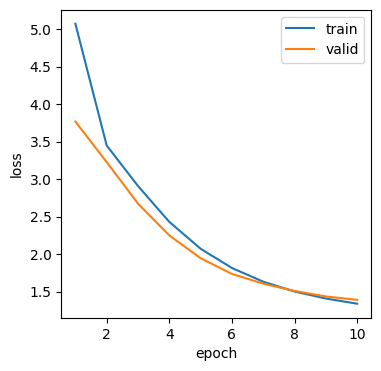

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4, 4))
epochs_range = range(1, len(history["train"]) + 1)
ax.plot(epochs_range, history["train"], label="train")
ax.plot(epochs_range, history["valid"], label="valid")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.legend()
plt.show()